In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import * 

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)


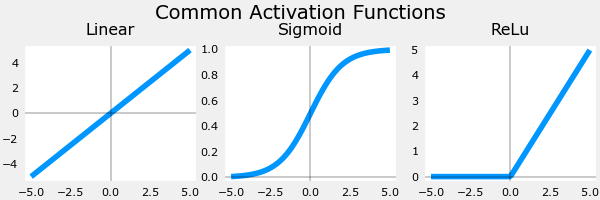

In [3]:
plt_act_trio()

In [4]:
#NUMPY 
def my_softmax(z):
    ez = np.exp(z)
    Sum = np.sum(ez)
    a = ez/Sum
    return a

In [7]:
z_test = np.array([1.0,2.0,3.0,4.0])
print(my_softmax(z_test))
test_my_softmax(my_softmax)

[0.03 0.09 0.24 0.64]
 All tests passed.


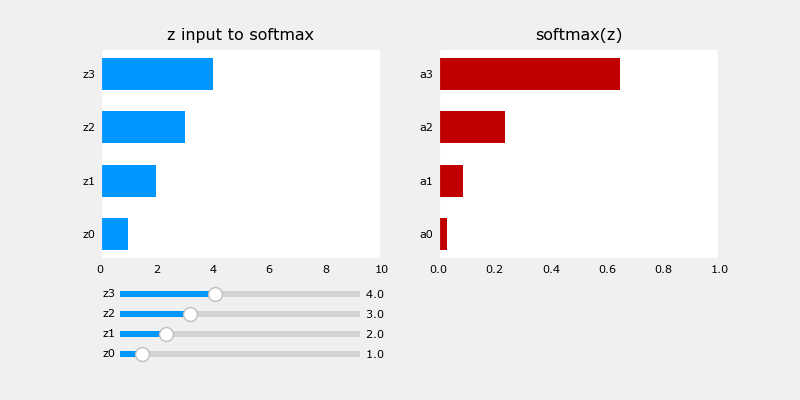

In [8]:
plt.close("all")
plt_softmax(my_softmax)

In [10]:
#LOADING DATASET
X, y = load_data()

In [11]:
#VIEWING THE VARIABLES
print(X[0])

[ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-01  2.78e-02 -7.06e-03
  2.35

In [13]:
print(y[0,0])
print(y[-1,0])

0
9


In [15]:
print(X.shape)
print(y.shape)

(5000, 400)
(5000, 1)


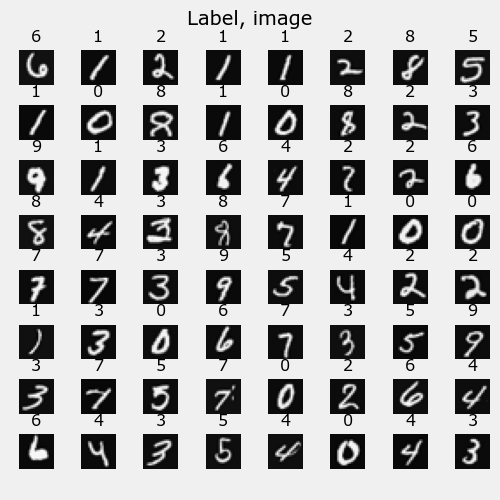

In [18]:
m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(5, 5))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.91])

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)

    X_random_reshaped = X[random_index].reshape((20, 20)).T
    ax.imshow(X_random_reshaped, cmap="gray")
    ax.set_title(y[random_index, 0])
    ax.set_axis_off()

fig.suptitle("Label, image", fontsize=14)
plt.show() 


In [43]:
# construct the three layer network

tf.random.set_seed(1234)
model = Sequential([
    Dense(25, activation='relu', input_shape=(400,)), 
    Dense(15, activation='relu'),
    Dense(10, activation='linear')
], name="my_mode"
                  )


In [44]:
model.summary()

Model: "my_mode"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
[layer1,layer2,layer3] = model.layers

In [47]:
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")


W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [50]:
# loss function
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
)
#The Training Execution
history = model.fit(
    X,y,
    epochs= 40
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - loss: 0.0269 
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step - loss: 0.0230
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 261us/step - loss: 0.0210
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - loss: 0.0192
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - loss: 0.0173
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - loss: 0.0157
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - loss: 0.0143
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - loss: 0.0129
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step - loss: 0.0118
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - loss: 0.0107
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step - loss: 0.0097
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 269us/step - loss: 0.0088
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step - loss: 0.0079
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 261us/step - loss: 0.0073
Epoch 15/40
157/157 ━━━━━━━━

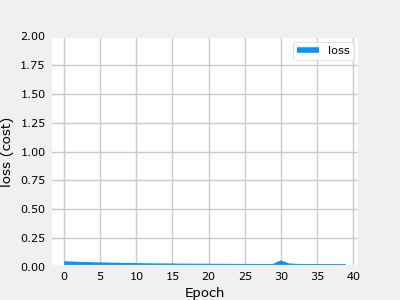

In [51]:
plot_loss_tf(history)

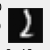

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
 predicting a Two: 
[[-26.31   0.84   5.28  -4.58 -15.46 -15.31 -18.19  -0.38 -14.96 -19.91]]
 Largest Prediction index: 2


In [52]:
#Prediction
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

In [53]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[1.87e-14 1.16e-02 9.85e-01 5.10e-05 9.63e-10 1.12e-09 6.27e-11 3.42e-03
  1.59e-09 1.13e-11]]
Total of predictions: 1.000


In [54]:
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


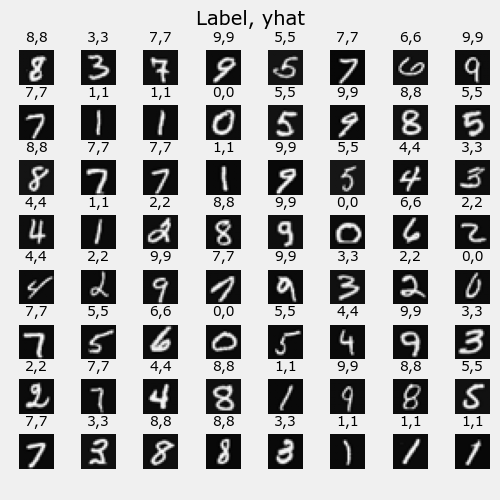

In [55]:
m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(5, 5))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.91])


for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random_reshaped = X[random_index].reshape((20, 20)).T


    ax.imshow(X_random_reshaped, cmap="gray")

    prediction = model.predict(X[random_index].reshape(1, 400), verbose=0)

    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    ax.set_title(f"{y[random_index, 0]},{yhat}", fontsize=10)
    ax.set_axis_off()

fig.suptitle("Label, yhat", fontsize=14)
plt.show() 

In [57]:
# 1. Generate predictions for ALL 5,000 images instantly
raw_predictions = model.predict(X, verbose=0)

# 2. Extract the winning digit index column for every row at once
yhat_all = np.argmax(raw_predictions, axis=1)

# 3. Flatten your true answer key 'y' from (5000, 1) down to (5000,)
y_flat = y.flatten()

# 4. Locate every single index row where the model's guess does not match the real answer
error_indices = np.where(yhat_all != y_flat)[0]

# 5. Output the official final scorecard tally
print(f"{len(error_indices)} errors out of {len(X)} images")


1 errors out of 5000 images
